# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Arya Kumar

**Date:** September 11, 2026

Answers for Question 1.1, 1.2, 1.3, and 1.4 are pictures uploaded to github repository

In [2]:
# Your Phase 1 solution to the problem goes here.
#Question 2.1
from google.colab import files
uploaded = files.upload()

Saving ForeignGifts_edu.csv to ForeignGifts_edu.csv


In [3]:
#I have imported the dataset and read it in as a dataframe. The dataset is recording foreign gifts and data about it.
import pandas as pd
df = pd.read_csv('ForeignGifts_edu.csv')
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [4]:
#Question 2.2
df["Foreign Gift Amount"].describe()
# Foreign Gift Amount ranges from about -$538,000 to $100 million. The median gift is about $94,615, while the mean is significantly higher at about $588,000. This variable has a distribution that is strongly right-skewed, with a relatively small number of very large gifts making the mean so high.

,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


(array([2.642e+04, 1.090e+03, 2.990e+02, 1.260e+02, 6.100e+01, 5.300e+01,
        1.600e+01, 1.600e+01, 1.500e+01, 1.300e+01, 7.000e+00, 8.000e+00,
        1.600e+01, 1.100e+01, 7.000e+00, 6.000e+00, 7.000e+00, 3.000e+00,
        0.000e+00, 7.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 3.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.400e+01, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 7.000e+00]),
 array([ -537770.        ,  1472985.38      ,  3483740.76      ,
         5494496.14      ,  7505251.52      ,  9516006.9       ,
        11526762.28      , 13537517.66      , 15548273.04      ,
        17559028.42      , 19569783.8       , 21580539.18      ,
        23591294.56      , 25602049.94      , 27612805.32      ,
        29623560.7       , 31634316.08      , 33645

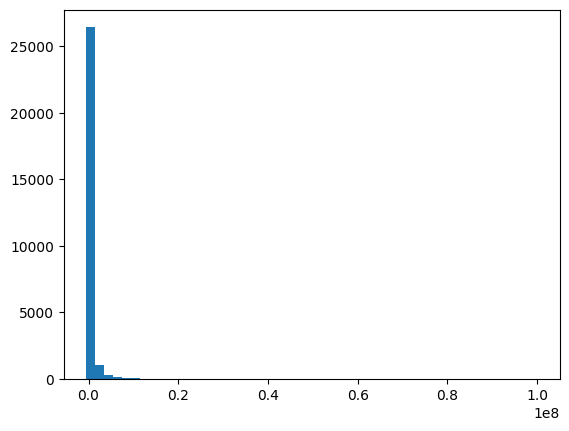

In [5]:
import matplotlib.pyplot as plt
plt.hist(df["Foreign Gift Amount"], bins=50)
#I made a histogram of the variable with 50 bins to see if that would help with the skew. There is still a very strong right skew and the mass majority of these gifts fall under the bin of 0 to 20 million dollar gifts. However since there is a maximum of a 100 million dollar gift,the historgram has this strong right skew.

In [6]:
#Question 2.3
#Looking at the amount of each type there is for gift type
df["Gift Type"].value_counts()

,count
Gift Type,
Contract,17274
Monetary Gift,10936
Real Estate,11


In [7]:
#calculating porpotions of each
#Approximately 61.2% is contract. 38.8% is monetary gift. 0.03% is real estate.
x = 17274 + 10936 + 11
print(17274/x)
print(10936/x)
print(11/x)

0.6120973742957372
0.3875128450444704
0.00038978065979235324


In [8]:
#2.4 Importing numpy and seaborn
import numpy as np
import seaborn as sns

I can't take logs of negative numbers. Not sure if I should be cleaning that as positive but my code will ignore those negative numbers for 2.4.

<Axes: xlabel='Log of Foreign Gift Amount', ylabel='Density'>

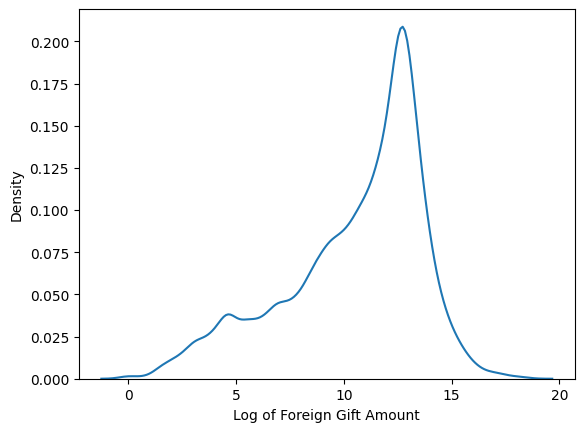

In [9]:
#Creating variable that is the log of foreign gift amount that drops negative value and creating kernel density plot of the logged vairable
df["Log of Foreign Gift Amount"] = df["Foreign Gift Amount"].drop(df[df["Foreign Gift Amount"] < 0].index)
df["Log of Foreign Gift Amount"] = np.log(df["Log of Foreign Gift Amount"])
sns.kdeplot(data=df, x="Log of Foreign Gift Amount")

<Axes: xlabel='Log of Foreign Gift Amount', ylabel='Density'>

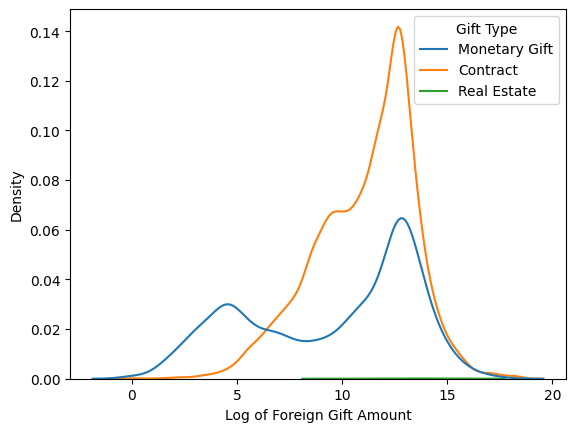

In [10]:
#now creating different kernel density plots based on gift type using the "hue" of gift type
# It appears that contract gifts are often larger relative to the other gift types. Contract gifts have the highest concentration around a log gift amount of 12–13 meaning they are concentrated at higher values rather than being evenely distrbuted at a low amount. Monetary gifts are more spread out at likely lower amounts. There are very few (11) real estate ones, so their density is close to zero.
sns.kdeplot(data=df, x="Log of Foreign Gift Amount", hue="Gift Type")

In [13]:
#Question 2.5
#Using value counts gives you the how many rows there are for each country sorted from most to lowest. Using head 15 attached to that additionally gives you to top 15.
df["Country of Giftor"].value_counts().head(15)

,count
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [22]:
#Next we want to know which top 15 countries gave the highest amount in any single given gift. We group countries and amounts given and then figure out what the max is for each country and sort those from highest to lowest and display only the top 15 using head.
df.groupby("Country of Giftor")["Foreign Gift Amount"].max().sort_values(ascending=False).head(15)

,Foreign Gift Amount
Country of Giftor,
AUSTRALIA,99999999
QATAR,99999999
BERMUDA,75000000
THAILAND,67700000
CANADA,48842186
HONG KONG,47670277
MONACO,47600000
UNITED ARAB EMIRATES,43021197
SAUDI ARABIA,43000000


In [16]:
#Question 2.6 Next we want to see top 15 countries by total amount given rather than just number of gifts or highest gift amount. We use the group by/sum functions here to figure this out. This sorts the countries by gift amount and d sums up all the gift amounts for each country in descneding order. Head 5 again gives us the five biggest giftors
df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(5)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:**
658eb18
- **AI tool and model used:** Chat gpt 5.6 sol

### *Prompts used

1. Question 1 revision prompt. I pasted all of my photos into chatgpt and along with a screenshot of the questions and asked - is there anything wrong with my equations or is there anything that I could improve on?

2. For question 2, I sent in a screenshot of every question and the corresponding code and uploaded the dataset to chat to see if they had anything to make beter about the code.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Says that 1.1 and 1.2 are correct. For 1.3, it says "The only thing I'd change is don't jump straight from here to \(b^2s^2\) and then back to covariance without explaining it. Explicitly write:

$$ =b^2\operatorname{cov}(X,X) $$

and therefore

cov(a+bX,a+bX)=b
2
cov(X,X)
	​
For 1.4, it says that my explanation is a little off. It gives this explanation as a little more precise. "This is not always true because a nonlinear transformation can change the distances between observations. Therefore, transforming each observation before taking the mean can produce a different result than taking the mean first and then transforming it."

2. For question 2. It gave some suggestions. For 2.2, it says to write plt(show) to prevent the array information from showing up. For question 2.4, it says my solution is fine, but it does not drop zeros which would be bad since log(0) is also not defined, but that it's not a problem since there are no zeros. It also suggests compressing my multiline code to df["Log of Foreign Gift Amount"] = np.log(
    df["Foreign Gift Amount"].where(df["Foreign Gift Amount"] > 0)
)
It also says in 2.4 that I wrote that contract gifts are often larger relative to the other gift types and that I cannot say that based on this graph because a higher density does not mean a larger amount.

For 2.5, I accidentally misintrepeted the question. It says the first part is fine but then I coded the highest single gift amount per country rather than total amount given. I actually answered the second part of 2.5 in my answering of 2.6 as I misintrepeted both questions.

For 2.6, I have not technically answered it since I misintrepeted the question. I should ansqewr the question like this. df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / **reject** | I reject the revision for 1.3. It says I made a "jump" but I'm doing the opposite which is going from S^2 to cov(x,x) instead of jumping straight to cov(x,x) to incorporate the first part of the proof from the question.
| 2 | Accept / modify / **reject** | I don't think it's saying something that's actually different than what I wrote. I suspect it could not read my handwriting that well maybe and it just said what it thinks the answer should be.
| 3. | Accept / modify / **reject** | For 2.2, I reject it, just because it does not really make a difference.
| 4 | **Accept** / modify / reject | For 2.4, I accept it because it is a good condensed version. I tried it out and ensured that I got the same answer.
| 5 | **Accept** / modify / reject | For 2.5, I accept that I should take my 2.6 answer and move it to the 2.5 to answer teh second half of 2.5.
| 6 | **Accept** / modify / reject | For 2.6, I accept that I misintrepeted the question and accept the suggested code it gave.

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [12]:
# Your Phase 2 solution to the problem goes here.


In [12]:
# Question 2.4 Chat revision

# Creating a variable that is the log of Foreign Gift Amount
# Values that are zero or negative cannot be logged, so they become NaN
df["Log of Foreign Gift Amount"] = np.log(
    df["Foreign Gift Amount"].where(df["Foreign Gift Amount"] > 0)
)

# Kernel density plot of log Foreign Gift Amount
sns.kdeplot(data=df, x="Log of Foreign Gift Amount")
plt.show()





In [ ]:
# Kernel density plot conditional on Gift Type
sns.kdeplot(data=df, x="Log of Foreign Gift Amount", hue="Gift Type")
plt.show()

# Monetary gifts have more density at lower logged gift amounts, while
# contracts are more concentrated around higher logged amounts near 12-13.
# Monetary gifts are more spread out and have multiple peaks.
# There are very few real estate gifts, so their distribution is difficult
# to interpret.

In [25]:
# Question 2.5

# Top 15 countries by NUMBER of gifts
df["Country of Giftor"].value_counts().head(15)

,count
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [24]:
# Top 15 countries by TOTAL AMOUNT given
df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(
    ascending=False
).head(15)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


In [26]:
# Question 2.6

# Giftors that provide the most money in total
df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(
    ascending=False
).head(15)

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

AI did a good job condensing the one of my longer solutions. I think some of it's condension was not super necessary and very nitpicky. I don't think it was super helpful for the proofs since it could not read my handwriting very well and it did not seem to actually be critiquing my explanation. It also caught me in some areas where I potentially forgot to drop a zero value and and caught my mistakes in misintrepreting 2.5 and 2.6. It caught that I misintreprteed teh end of 2.5 and 2.6 which I gave completely wrong answers to, and it was able to replicate the style of code I had given it but apply what the question was actually asking for. I think it's nice to get rid of teh array information for the histograms, but I don;t think it is a real correction.